# This notebook is designed to:

1. **Load and preprocess** SimGlucose episode data (e.g., from DT/ODT evaluations).  
2. **Define glycemic state ranges**: hypoglycemia, euglycemia, and hyperglycemia.  
3. **Calculate the fraction of time** spent in each glycemic state per episode.  
4. **Visualize and compare results** across different models or configurations.

In [7]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import numpy as np

# Step 1: Load the dataset
# Replace the path with the correct path to your .pkl file
with open('T1DatasetAnalysis/BB/output_noisy/adolescent#001/adolescent#001_combined_seed.pkl', 'rb') as f:
    data = pickle.load(f)

# Inspect the data
print("Dataset type:", type(data))
print("Length of data:", len(data))
print("First few entries:", data[:5])

Dataset type: <class 'list'>
Length of data: 20
First few entries: [{'observations': array([[165.79395],
       [161.58202],
       [159.23938],
       ...,
       [134.31784],
       [132.71117],
       [133.70993]], dtype=float32), 'next_observations': array([[161.58202],
       [159.23938],
       [157.4727 ],
       ...,
       [132.71117],
       [133.70993],
       [133.70993]], dtype=float32), 'actions': array([[0.01393333],
       [0.01393333],
       [0.01393333],
       ...,
       [0.01393333],
       [0.01393333],
       [0.        ]], dtype=float32), 'rewards': array([1., 1., 1., ..., 1., 1., 1.], dtype=float32), 'terminals': array([False, False, False, ..., False, False,  True])}, {'observations': array([[165.79395],
       [161.58202],
       [159.23938],
       ...,
       [133.73637],
       [131.2245 ],
       [131.32509]], dtype=float32), 'next_observations': array([[161.58202],
       [159.23938],
       [157.4727 ],
       ...,
       [131.2245 ],
       [131.32509

In [8]:
# Step 2: Extract glucose levels from the list
# Since the data is a list, we need to determine its structure
# Assumption: The list contains glucose readings directly (e.g., [glucose1, glucose2, ...])
# If the list contains nested structures (e.g., list of dictionaries or lists), adjust accordingly
if isinstance(data, list):
    # Check if the list contains nested structures
    if isinstance(data[0], (list, dict, np.ndarray)):
        # If nested, we need to flatten or extract the glucose values
        # Example: If data is a list of arrays or lists, flatten it
        glucose_data = []
        for item in data:
            if isinstance(item, (list, np.ndarray)):
                glucose_data.extend(item)
            elif isinstance(item, dict):
                # If it's a dict, extract the relevant key (e.g., 'glucose' or 'observations')
                glucose_data.extend(item.get('glucose', item.get('observations', [])))
    else:
        # If the list contains scalar values (glucose readings), use it directly
        glucose_data = data
else:
    raise ValueError("Expected data to be a list, but got type:", type(data))

# Convert to a Pandas Series for easier manipulation
glucose_series = pd.Series(glucose_data)

# Inspect the glucose data
print("\nGlucose data (first 5 entries):", glucose_series.head())
print("Number of glucose readings:", len(glucose_series))


Glucose data (first 5 entries): 0    [165.79395]
1    [161.58202]
2    [159.23938]
3     [157.4727]
4    [156.10895]
dtype: object
Number of glucose readings: 96020


In [9]:
# Step 3: Define glycemic state thresholds (in mg/dL)
HYPOGLYCEMIA_THRESHOLD = 70
HYPERGLYCEMIA_THRESHOLD = 180

# Categorize glucose levels into glycemic states
def categorize_glycemic_state(glucose):
    try:
        glucose = float(glucose)  # Ensure the value is numeric
        if glucose < HYPOGLYCEMIA_THRESHOLD:
            return 'Hypoglycemia'
        elif HYPOGLYCEMIA_THRESHOLD <= glucose <= HYPERGLYCEMIA_THRESHOLD:
            return 'Euglycemia'
        else:
            return 'Hyperglycemia'
    except (ValueError, TypeError):
        return 'Invalid'  # Handle non-numeric values

# Apply categorization
glycemic_states = glucose_series.apply(categorize_glycemic_state)

# Check for invalid entries
invalid_count = (glycemic_states == 'Invalid').sum()
if invalid_count > 0:
    print(f"Warning: Found {invalid_count} invalid glucose readings (non-numeric values).")

# Filter out invalid entries for analysis
glycemic_states = glycemic_states[glycemic_states != 'Invalid']

In [10]:
# Step 4: Compute the fraction of time in each state
state_counts = glycemic_states.value_counts()
total_readings = len(glycemic_states)
state_fractions = state_counts / total_readings

# Print the results
print("\nFraction of time spent in each glycemic state:")
print(state_fractions)


Fraction of time spent in each glycemic state:
Euglycemia       0.886524
Hyperglycemia    0.112966
Hypoglycemia     0.000510
Name: count, dtype: float64


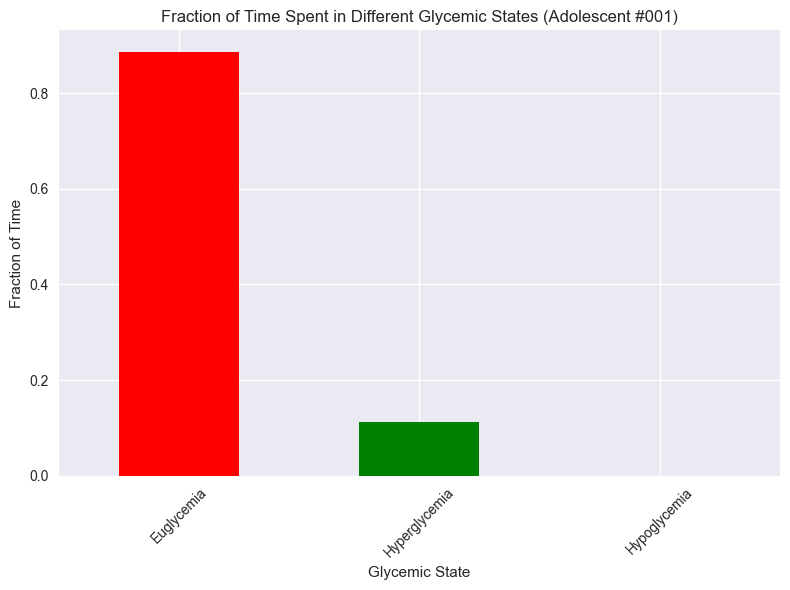

In [11]:
# Step 5: Visualize the results
plt.figure(figsize=(8, 6))
state_fractions.plot(kind='bar', color=['red', 'green', 'orange'])
plt.title('Fraction of Time Spent in Different Glycemic States (Adolescent #001)')
plt.xlabel('Glycemic State')
plt.ylabel('Fraction of Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()